# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 4 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.


In [3]:
import Pkg;
Pkg.add("JuMP")
Pkg.add("GLPK")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
   Installed GLPK_jll ─ v5.0.1+1
   Installed GLPK ───── v1.2.1
  Installing 1 artifacts
   Installed artifact GLPK                     3.1 MiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [60bf3e95] + GLPK v1.2.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [60bf3e95] + GLPK v1.2.1
  [e8aa6df9] + GLPK_jll v5.0.1+1
  [781609d7] + GMP_jll v6.3.0+2
Precompiling packages...
    724.6 ms  ✓ GLPK_jll
   5730.6 ms  ✓ GLPK
  2 dependencies successfully precompiled in 7 seconds. 257 already precompiled.


# Broń boże nie ściągajcie najnowszej wersji Evolutionary tylko wersję 0.10.1

# ZADANIE 1

In [1]:
using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 50
k = 20
X, Y, d, cost_item_city = generate_random_tpp(n, k)

([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  47.07715605583087, 45.74787799446105, 39.31968187864505, 95.05129878297356, 78.35752622358207, 64.99869009136225, 13.167067492229867, 12.318877197601253, 19.319307029658294, 92.85029082227491], [37.858565883918295, 25.984947956264225, 71.67867297426689, 1.0898739765043075, 84.7785926801192, 35.36099955711283, 98.58458165854893, 73.65713555150472, 1.992039852101013, 70.72355934304049  …  84.87369607977678, 61.680928138712, 5.665730912653899, 15.622563304879634, 36.90767228785501, 70.07597765092129, 79.43901471209098, 46.482254570311675, 68.59072330642508, 86.69884288310024], [0.0 61.44219730376061 … 32.13916398865862 96.24866724284715; 61.44219730376061 0.0 … 66.3618156785821 64.80204173406327; … ; 32.13916398865862 66.3618156785821 … 0.0 75.72786522881266; 96.24866724284715 64.80204173406327 … 7

### Metoda iteracyjna

In [2]:
function build_tpp_model(d, n, cost_item_city, m)
    model = Model(GLPK.Optimizer)

    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, z[1:m, 1:n], Bin)

    @objective(model, Min, (sum(d .* x)/2) + sum(cost_item_city .* z))

    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)

    @constraint(model, [k in 1:m], sum(z[k,:]) == 1)
    return model
end

build_tpp_model (generic function with 1 method)

In [3]:
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

subtour (generic function with 1 method)

In [4]:
function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

selected_edges (generic function with 1 method)

In [5]:
subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(JuMP.value.(x))

subtour (generic function with 3 methods)

In [9]:
iterative_model = build_tpp_model(d, n, cost_item_city, k)
optimize!(iterative_model)
@assert is_solved_and_feasible(iterative_model)
time_iterated = solve_time(iterative_model)
cycle = subtour(iterative_model[:x])
while 1 < length(cycle) < n
    println("Found cycle of length $(length(cycle))")
    S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
    @constraint(
        iterative_model,
        sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
    )
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    global time_iterated += solve_time(iterative_model)
    global cycle = subtour(iterative_model[:x])
end

objective_value(iterative_model)

Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 6
Found cycle of length 5
Found cycle of length 3
Found cycle of length 4
Found cycle of length 6
Found cycle of length 4
Found cycle of length 8
Found cycle of length 5
Found cycle of length 10
Found cycle of length 10
Found cycle of length 15
Found cycle of length 11
Found cycle of length 4
Found cycle of length 22
Found cycle of length 3
Found cycle of length 5
Found cycle of length 21


5820.747873603571

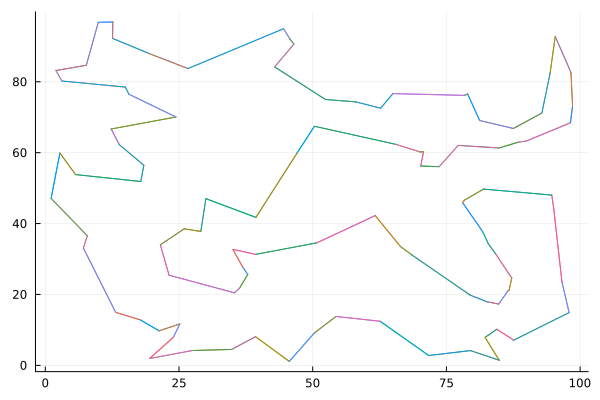

In [10]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, value.(iterative_model[:x]))

In [54]:
function plot_tour_with_shopping(model,X,Y,n,k)
    x_val = value.(model[:x])
    z_val = value.(model[:z])

    p = Plots.plot(legend=false)
    for (i,j) in selected_edges(x_val,n)
        Plots.plot!([X[i],X[j]],[Y[i],Y[j]])
    end

    for i in 1:n
        items_count = sum(z_val[:,i])
        if items_count>0
            msize = 1 + 2*items_count
            Plots.scatter!([X[i]],[Y[i]],
                color=:green,
                markersize=msize,
                label="")
        end
    end
    return p
end

plot_tour_with_shopping (generic function with 2 methods)

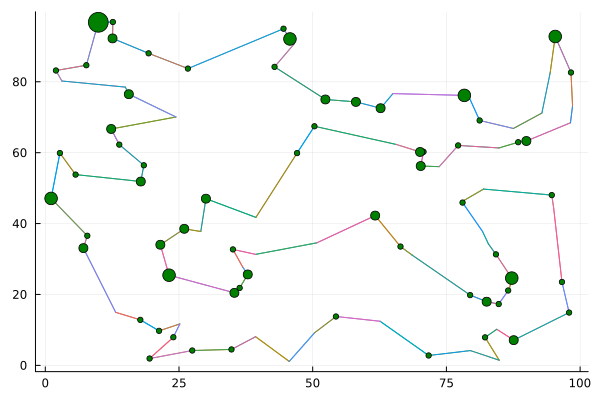

In [55]:
plot_tour_with_shopping(iterative_model,X,Y,n,k)

In [46]:
using DataFrames

function get_shopping_df(model,n,k)
    z_val = value.(model[:z])
    df = DataFrame(Produkt = Int[], Miasto = Int[], Cena = Float64[])

    for p in 1:k, i in 1:n
        if z_val[p,i] > 0.5
            push!(df,(p,i,cost_item_city[p,i]))
        end
    end
    show(df,allrows=true, show_row_number=false,eltypes=false,summary=false)
end

get_shopping_df (generic function with 2 methods)

In [47]:
get_shopping_df(iterative_model,n,k)

 Produkt  Miasto  Cena    
──────────────────────────
       1      77  51.0638
       2       5  51.2822
       3       9  51.6528
       4      51  50.5986
       5      24  50.1819
       6      28  50.0479
       7       4  50.496
       8      31  51.0643
       9      33  50.725
      10      93  50.0645
      11      19  52.7328
      12      13  50.6884
      13      34  50.1036
      14      36  52.5847
      15      76  50.5709
      16      40  50.9579
      17      88  51.0534
      18      17  51.5644
      19      30  50.0412
      20       2  50.1949
      21      90  51.1239
      22      67  50.7379
      23      16  50.3716
      24      40  50.6579
      25       8  50.3766
      26      66  50.7261
      27      55  50.0883
      28      25  50.707
      29      60  50.791
      30      23  50.1183
      31       1  50.8029
      32      73  50.2584
      33      37  50.6933
      34      42  50.8525
      35      51  50.8959
      36      34  50.2069
      37      

### Metoda genetyczna

In [6]:
using Evolutionary
using Random

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

RP = randperm(20)
iRP = perm_to_inv(RP)
println(RP == inv_to_perm(iRP))

true


In [7]:
function has_subtour(perm::Vector)
    c = 1
    for i in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

has_subtour (generic function with 1 method)

In [8]:
function mutate_swap(recombinant::AbstractVector;rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end


"""

Implementation follows "Genetic Algorithm Solution of the TSP Avoiding Special Crossover and Mutation"
"""
function recombine_tsp(v1::T, v2::T; rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    crossover_point = rand(2:(N-1))
    i1c = vcat(i1[1:crossover_point], i2[(crossover_point+1):N])
    i2c = vcat(i2[1:crossover_point], i1[(crossover_point+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

recombine_tsp

In [65]:
n = 50
k = 50
X, Y, d, cost_item_city = generate_random_tpp(n, k)

([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  47.07715605583087, 45.74787799446105, 39.31968187864505, 95.05129878297356, 78.35752622358207, 64.99869009136225, 13.167067492229867, 12.318877197601253, 19.319307029658294, 92.85029082227491], [37.858565883918295, 25.984947956264225, 71.67867297426689, 1.0898739765043075, 84.7785926801192, 35.36099955711283, 98.58458165854893, 73.65713555150472, 1.992039852101013, 70.72355934304049  …  84.87369607977678, 61.680928138712, 5.665730912653899, 15.622563304879634, 36.90767228785501, 70.07597765092129, 79.43901471209098, 46.482254570311675, 68.59072330642508, 86.69884288310024], [0.0 61.44219730376061 … 32.13916398865862 96.24866724284715; 61.44219730376061 0.0 … 66.3618156785821 64.80204173406327; … ; 32.13916398865862 66.3618156785821 … 0.0 75.72786522881266; 96.24866724284715 64.80204173406327 … 7

In [133]:
x0 = [mod1(i+1, n) for i in 1:n]
function cost(x)
    dist = 0.0
    for i in 1:length(x)
        dist += d[i, x[i]]
    end
    if has_subtour(x)
        dist += 5000
    end
    shopping_cost = sum(minimum(cost_item_city[:, x], dims=2))
    return dist + shopping_cost
end
println("Initial cost: $(cost(x0))")

Initial cost: 3504.6196624639356


In [67]:
x_sol = Evolutionary.optimize(
    cost,
    x0,
    GA(; populationSize=100000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
println(has_subtour(x_sol.minimizer))
println(x_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [11, 18, 22,  ...]
    Minimum:    4363.433687067821
    Iterations: 37

 * Found with
    Algorithm: GA[P=100000,x=0.9,μ=0.1,ɛ=0.01]

 * Work counters
    Seconds run:   53.5841 (vs limit Inf)
    Iterations:    37
    f(x) calls:    3800008



In [68]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    scatter!(X, Y)
    for i in 1:length(x)
        j = x[i]
        Plots.plot!(plot, [X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour (generic function with 1 method)

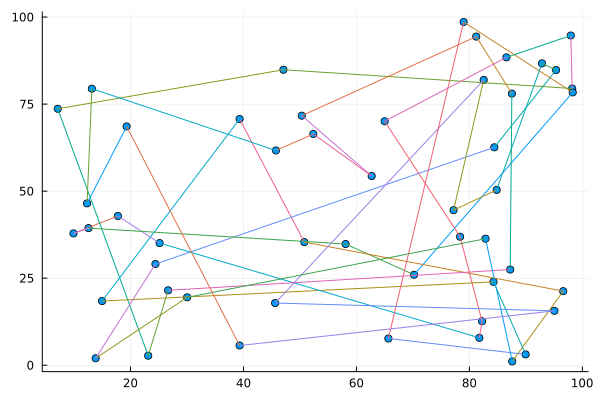

In [69]:
using Plots
plot_tour(X, Y, x_sol.minimizer)

In [11]:
using Printf
function compare_methods(n,k)
    X, Y, d, cost_item_city = generate_random_tpp(n, k)
    time_iterative = @elapsed begin
        iterative_model = build_tpp_model(d, n, cost_item_city, k)
        optimize!(iterative_model)
        @assert is_solved_and_feasible(iterative_model)
        cycle = subtour(iterative_model[:x])
        while 1 < length(cycle) < n
            S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
            @constraint(
                iterative_model,
                sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
            )
            optimize!(iterative_model)
            @assert is_solved_and_feasible(iterative_model)
            cycle = subtour(iterative_model[:x])
        end
    end
    value_iterative = objective_value(iterative_model)

    function cost_local(x)
        dist = 0.0
        for i in 1:length(x)
            dist += d[i, x[i]]
        end
        if has_subtour(x)
            dist += 5000
        end
        shopping_cost = sum(minimum(cost_item_city[:, x], dims=2))
        return dist + shopping_cost
    end


    time_genetic = @elapsed begin
        x0 = [mod1(i+1, n) for i in 1:n]
        x_sol = Evolutionary.optimize(
            cost_local,
            x0,
            GA(; populationSize=10000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.01, crossoverRate=0.9),
            Evolutionary.Options(; iterations=10000)
        )
    end
    value_genetic = Evolutionary.minimum(x_sol)
    @printf("%15.2f | %15.4f | %15.2f | %15.4f | %3d | %3d\n",value_iterative,time_iterative,value_genetic,time_genetic,n,k)
end

compare_methods (generic function with 1 method)

In [12]:
println("VALUE ITERATIVE |  TIME ITERATIVE |   VALUE GENETIC |    TIME GENETIC |   N |   K")
compare_methods(50,20)
compare_methods(50,20)
compare_methods(50,20)

compare_methods(50,50)
compare_methods(50,50)
compare_methods(50,50)

# compare_methods(100,100)
# compare_methods(100,100)
# compare_methods(100,100)

VALUE ITERATIVE |  TIME ITERATIVE |   VALUE GENETIC |    TIME GENETIC |   N |   K
        1569.95 |          0.0414 |         2911.02 |          1.8019 |  50 |  20
        1569.95 |          0.0407 |         3070.41 |          1.8562 |  50 |  20
        1569.95 |          0.0424 |         3009.17 |          3.3591 |  50 |  20
        3119.10 |          0.0615 |         4559.39 |          4.0264 |  50 |  50
        3119.10 |          0.0630 |         4465.31 |          4.5320 |  50 |  50
        3119.10 |          0.0611 |         4581.57 |          4.3601 |  50 |  50
